In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e12/sample_submission.csv
/kaggle/input/playground-series-s4e12/train.csv
/kaggle/input/playground-series-s4e12/test.csv


In [2]:
from sklearn import linear_model, model_selection, preprocessing
from yellowbrick.regressor import ResidualsPlot

In [3]:
train_df=pd.read_csv('/kaggle/input/playground-series-s4e12/train.csv')

In [4]:
test_df=pd.read_csv('/kaggle/input/playground-series-s4e12/test.csv')

In [5]:
train_df.shape

(1200000, 21)

In [6]:
train_df.head().T

,0,1,2,3,4
id,0,1,2,3,4
Age,19.0,39.0,23.0,21.0,21.0
Gender,Female,Female,Male,Male,Male
Annual Income,10049.0,31678.0,25602.0,141855.0,39651.0
Marital Status,Married,Divorced,Divorced,Married,Single
Number of Dependents,1.0,3.0,3.0,2.0,1.0
Education Level,Bachelor's,Master's,High School,Bachelor's,Bachelor's
Occupation,Self-Employed,NaN,Self-Employed,NaN,Self-Employed
Health Score,22.598761,15.569731,47.177549,10.938144,20.376094
Location,Urban,Rural,Suburban,Rural,Rural


In [7]:
test_df.head().T

,0,1,2,3,4
id,1200000,1200001,1200002,1200003,1200004
Age,28.0,31.0,47.0,28.0,24.0
Gender,Female,Female,Female,Female,Male
Annual Income,2310.0,126031.0,17092.0,30424.0,10863.0
Marital Status,NaN,Married,Divorced,Divorced,Divorced
Number of Dependents,4.0,2.0,0.0,3.0,2.0
Education Level,Bachelor's,Master's,PhD,PhD,High School
Occupation,Self-Employed,Self-Employed,Unemployed,Self-Employed,Unemployed
Health Score,7.657981,13.381379,24.354527,5.136225,11.844155
Location,Rural,Suburban,Urban,Suburban,Suburban


In [8]:
train_df.isna().sum()#.plot(kind='barh')

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [9]:
test_df.isna().sum()#.plot(kind='barh')

id                           0
Age                      12489
Gender                       0
Annual Income            29860
Marital Status           12336
Number of Dependents     73130
Education Level              0
Occupation              239125
Health Score             49449
Location                     0
Policy Type                  0
Previous Claims         242802
Vehicle Age                  3
Credit Score             91451
Insurance Duration           2
Policy Start Date            0
Customer Feedback        52276
Smoking Status               0
Exercise Frequency           0
Property Type                0
dtype: int64

## Numerical fields

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual Income'}>,
        <Axes: title={'center': 'Number of Dependents'}>],
       [<Axes: title={'center': 'Health Score'}>,
        <Axes: title={'center': 'Previous Claims'}>,
        <Axes: title={'center': 'Vehicle Age'}>],
       [<Axes: title={'center': 'Credit Score'}>,
        <Axes: title={'center': 'Insurance Duration'}>,
        <Axes: title={'center': 'Premium Amount'}>]], dtype=object)

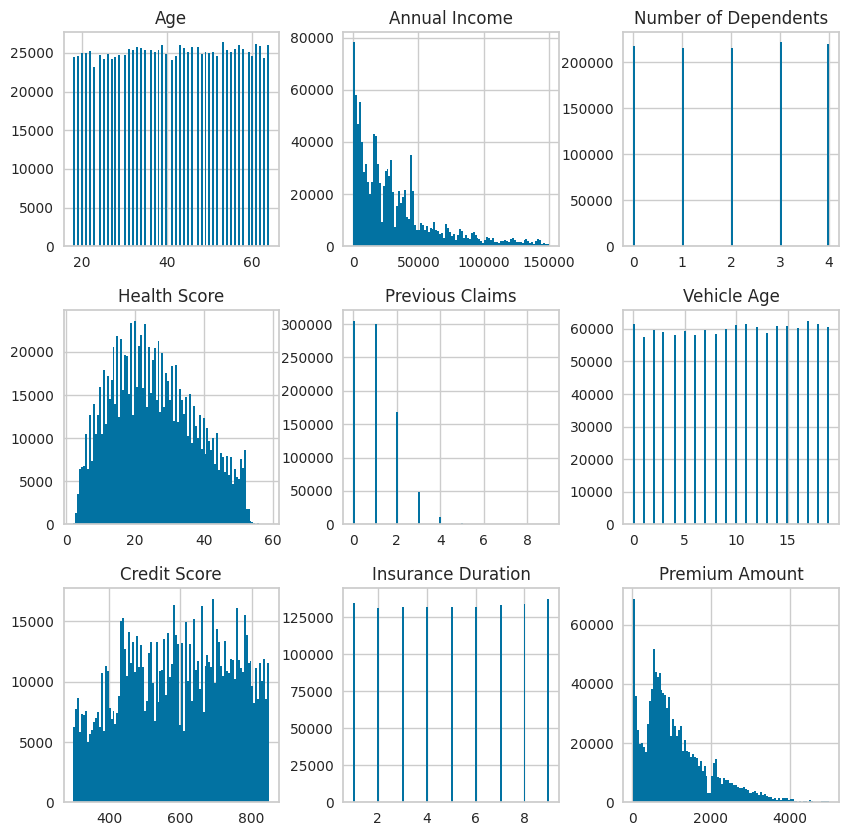

In [10]:
train_df.drop('id',axis='columns').hist(figsize=[10,10],bins=100)

* A number of fields are integer

<Axes: >

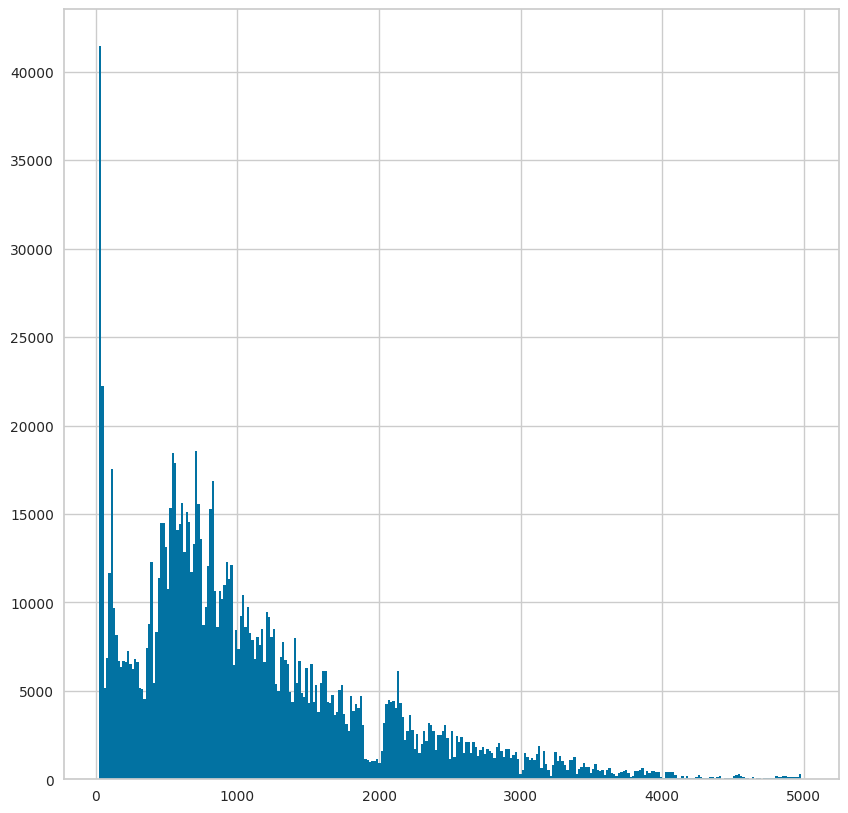

In [11]:
train_df['Premium Amount'].hist(figsize=[10,10],bins=300)

three distinct regions?

In [12]:
train_df.drop('id',axis='columns').corr(numeric_only=True)

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
Age,1.000000,-0.000009,0.001475,0.000881,0.001869,-0.002455,0.002842,-0.000064,-0.002430
Annual Income,-0.000009,1.000000,0.002135,0.025530,0.043065,-0.000500,-0.201423,0.000379,-0.012390
Number of Dependents,0.001475,0.002135,1.000000,0.005152,-0.004123,0.001232,-0.001714,-0.000265,-0.000976
Health Score,0.000881,0.025530,0.005152,1.000000,0.001989,0.000316,0.012016,0.002487,0.014704
Previous Claims,0.001869,0.043065,-0.004123,0.001989,1.000000,-0.001172,0.036816,0.003001,0.046874
Vehicle Age,-0.002455,-0.000500,0.001232,0.000316,-0.001172,1.000000,0.000508,0.003132,0.000391
Credit Score,0.002842,-0.201423,-0.001714,0.012016,0.036816,0.000508,1.000000,0.000493,-0.026014
Insurance Duration,-0.000064,0.000379,-0.000265,0.002487,0.003001,0.003132,0.000493,1.000000,-0.000028
Premium Amount,-0.002430,-0.012390,-0.000976,0.014704,0.046874,0.000391,-0.026014,-0.000028,1.000000


Credit score against annual income is the one worth exploring

/opt/conda/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


<Axes: xlabel='Credit Score', ylabel='Annual Income'>

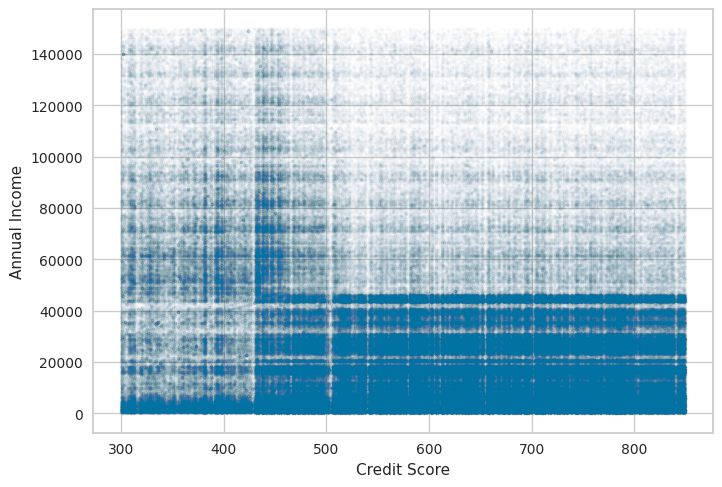

In [13]:
train_df.plot(kind='scatter',x='Credit Score',y='Annual Income',marker='.',alpha=0.01)

<Axes: xlabel='Credit Score', ylabel='Annual Income'>

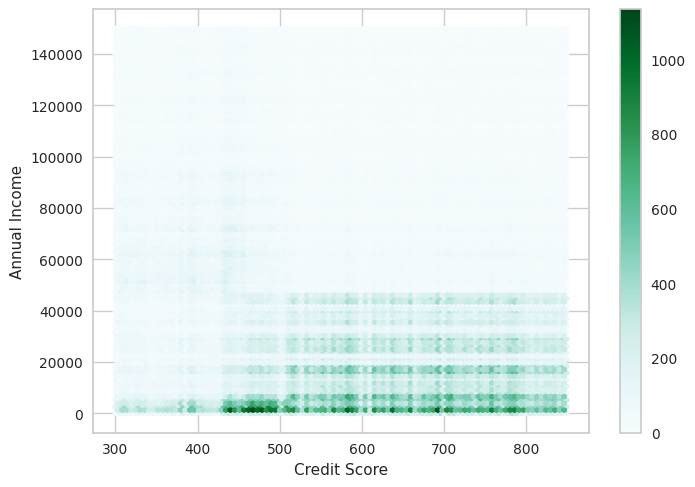

In [14]:
train_df.plot(kind='hexbin',x='Credit Score',y='Annual Income')

ok a bit all over the place, no wonder r is 0.2 only

array([[<Axes: title={'center': 'nan'}>, <Axes: title={'center': '0.0'}>,
        <Axes: title={'center': '1.0'}>],
       [<Axes: title={'center': '2.0'}>, <Axes: title={'center': '3.0'}>,
        <Axes: title={'center': '4.0'}>],
       [<Axes: title={'center': '5.0'}>, <Axes: title={'center': '6.0'}>,
        <Axes: title={'center': '7.0'}>],
       [<Axes: title={'center': '8.0'}>, <Axes: title={'center': '9.0'}>,
        <Axes: >]], dtype=object)

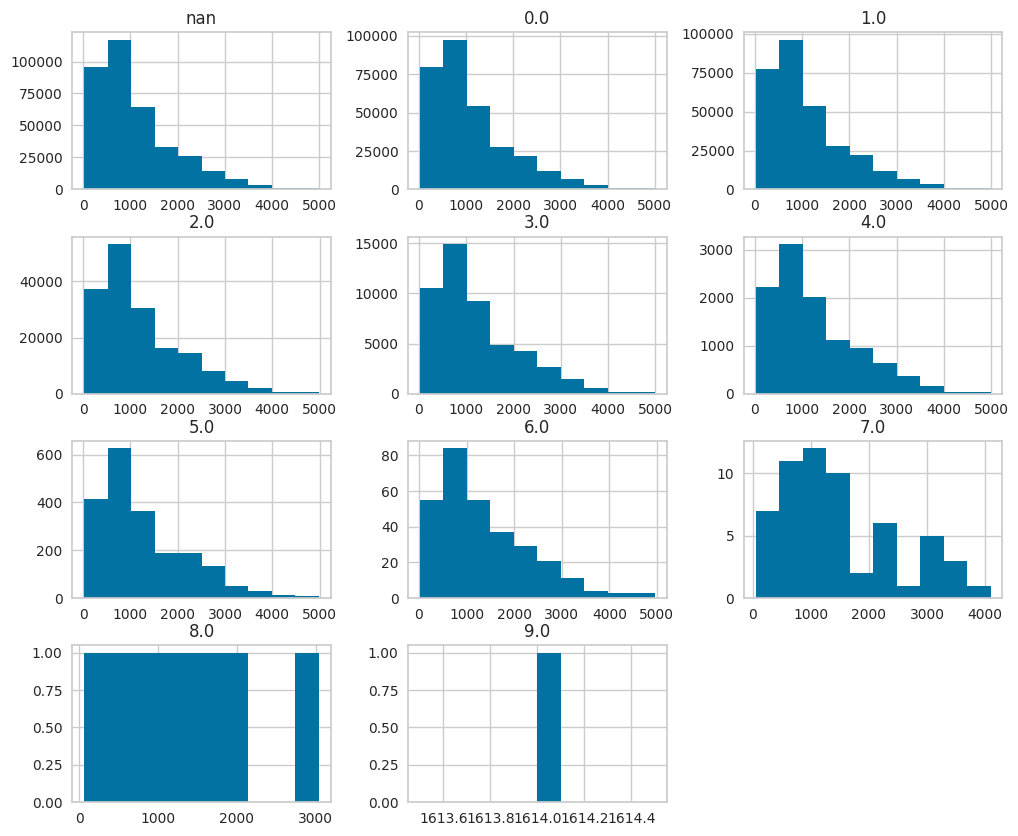

In [15]:
train_df.pivot(columns='Previous Claims',values='Premium Amount').hist(figsize=[12,10])

## Categorical fields

### Gender

<Axes: xlabel='Gender'>

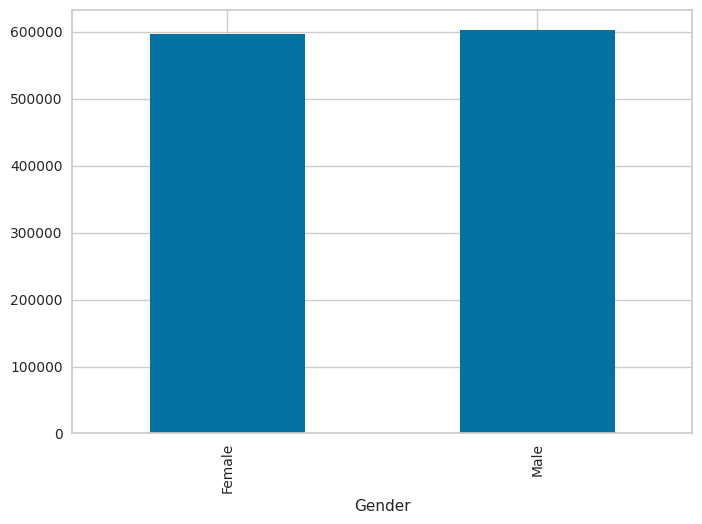

In [16]:
train_df.fillna('empty').groupby('Gender').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Female')"}>,
        <Axes: title={'center': "('Premium Amount', 'Male')"}>]],
      dtype=object)

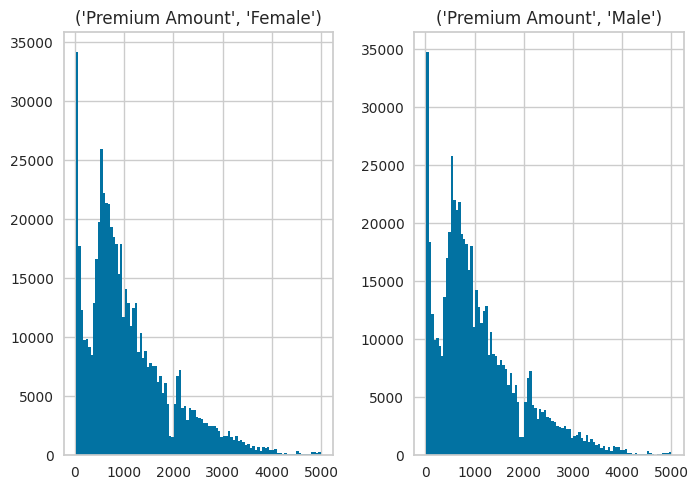

In [17]:
train_df[['Gender','Premium Amount']].pivot(columns='Gender').hist(bins=100)

### Marital status

<Axes: xlabel='Marital Status'>

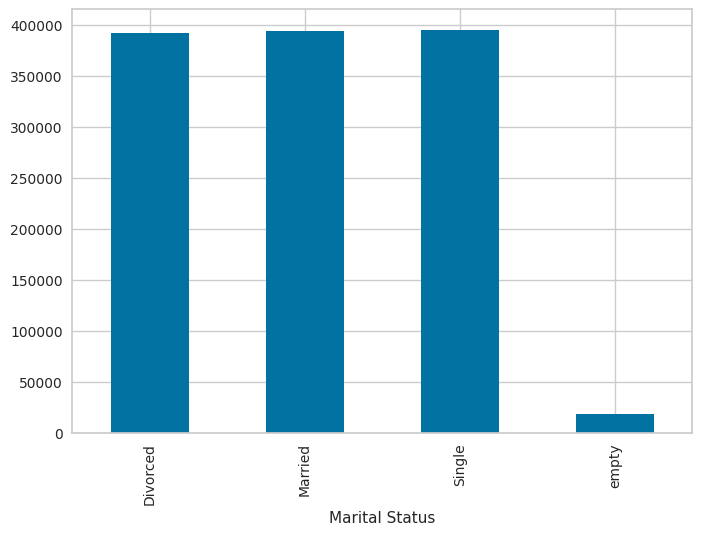

In [18]:
train_df.fillna('empty').groupby('Marital Status').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Divorced')"}>,
        <Axes: title={'center': "('Premium Amount', 'Married')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Single')"}>,
        <Axes: title={'center': "('Premium Amount', 'empty')"}>]],
      dtype=object)

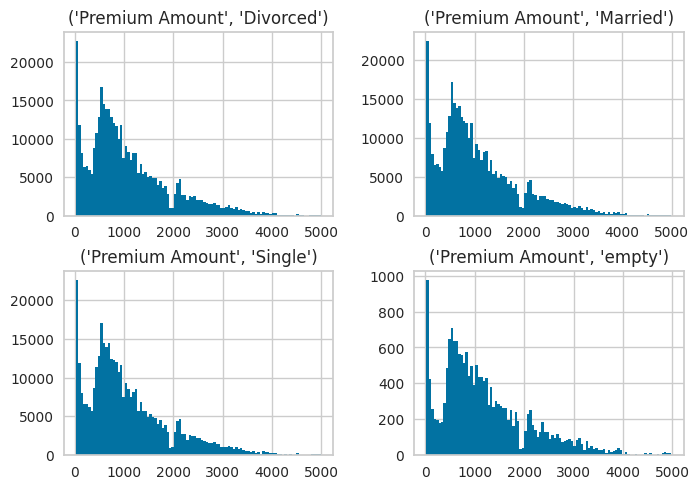

In [19]:
train_df.fillna('empty')[['Marital Status','Premium Amount']].pivot(columns='Marital Status').hist(bins=100)

### Education Level

<Axes: xlabel='Education Level'>

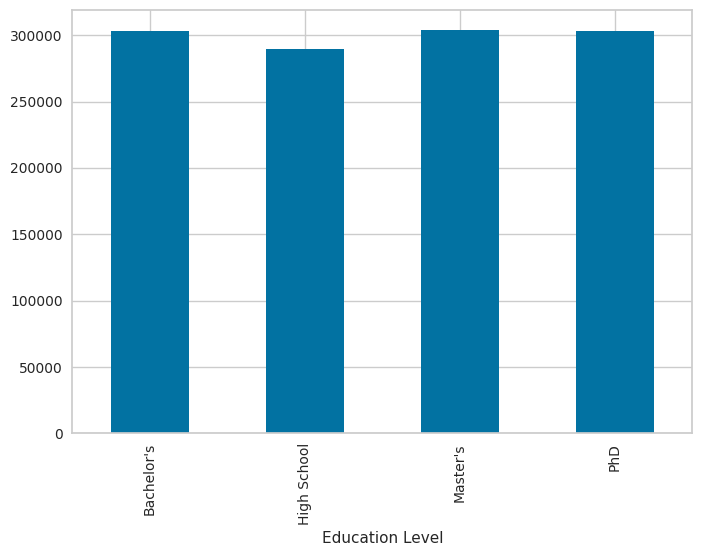

In [20]:
train_df.fillna('empty').groupby('Education Level').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': '(\'Premium Amount\', "Bachelor\'s")'}>,
        <Axes: title={'center': "('Premium Amount', 'High School')"}>],
       [<Axes: title={'center': '(\'Premium Amount\', "Master\'s")'}>,
        <Axes: title={'center': "('Premium Amount', 'PhD')"}>]],
      dtype=object)

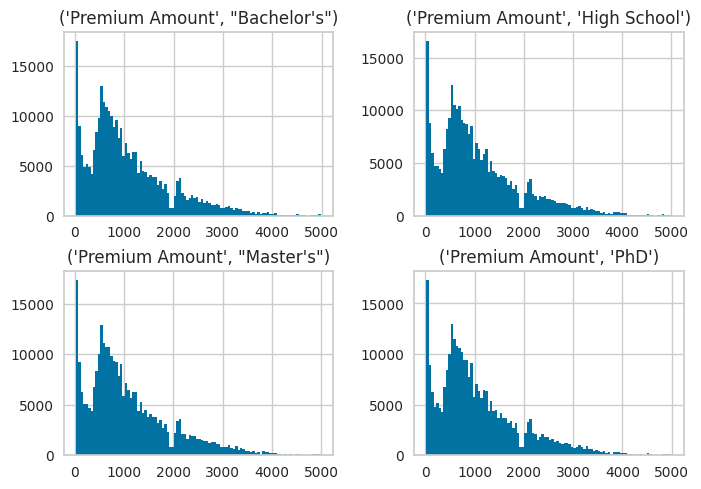

In [21]:
train_df.fillna('empty')[['Education Level','Premium Amount']].pivot(columns='Education Level').hist(bins=100)

### Occupation

<Axes: xlabel='Occupation'>

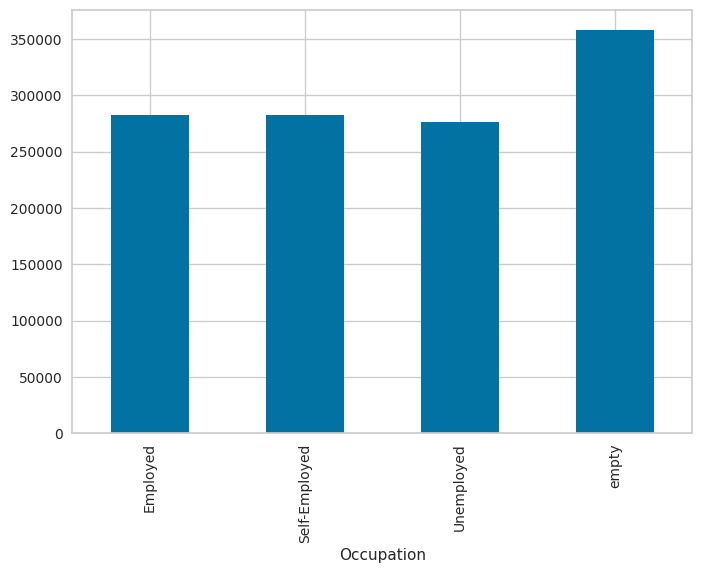

In [22]:
train_df.fillna('empty').groupby('Occupation').count()['id'].plot(kind='bar')

Empty occupation quite a problem for this dataset.

array([[<Axes: title={'center': "('Premium Amount', 'Employed')"}>,
        <Axes: title={'center': "('Premium Amount', 'Self-Employed')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Unemployed')"}>,
        <Axes: title={'center': "('Premium Amount', 'empty')"}>]],
      dtype=object)

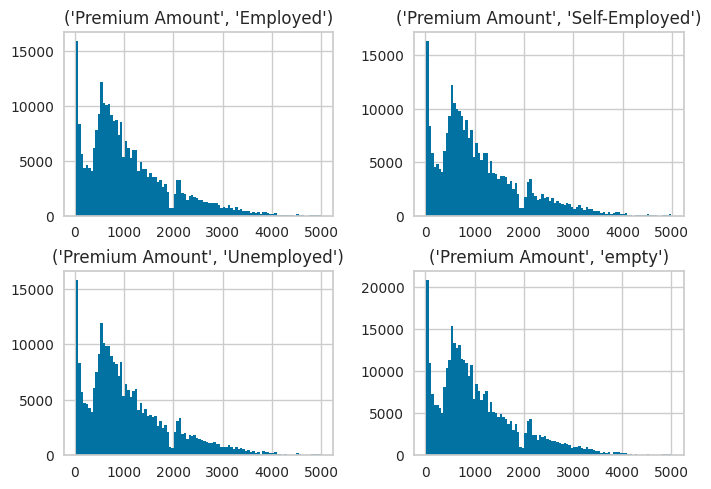

In [23]:
train_df.fillna('empty')[['Occupation','Premium Amount']].pivot(columns='Occupation').hist(bins=100)

### Location

<Axes: xlabel='Location'>

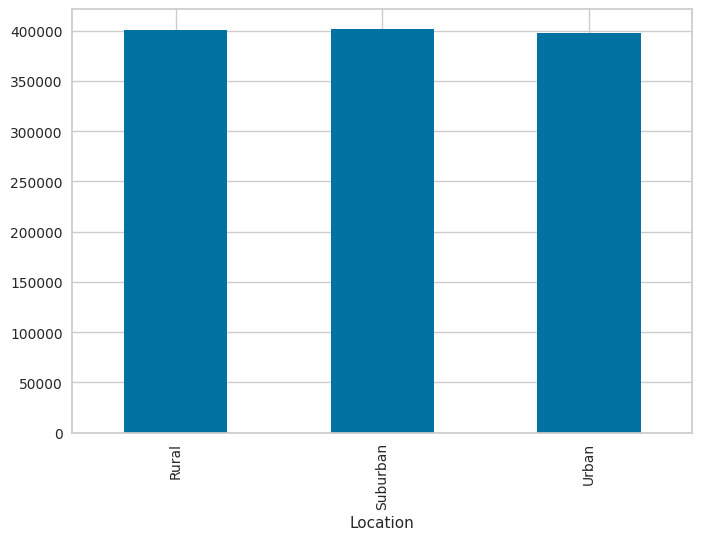

In [24]:
train_df.fillna('empty').groupby('Location').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Rural')"}>,
        <Axes: title={'center': "('Premium Amount', 'Suburban')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Urban')"}>,
        <Axes: >]], dtype=object)

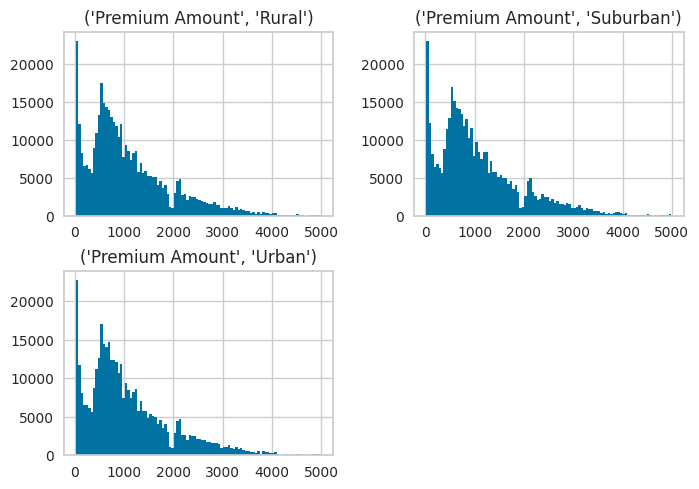

In [25]:
train_df.fillna('empty')[['Location','Premium Amount']].pivot(columns='Location').hist(bins=100)

### Policy type

<Axes: xlabel='Policy Type'>

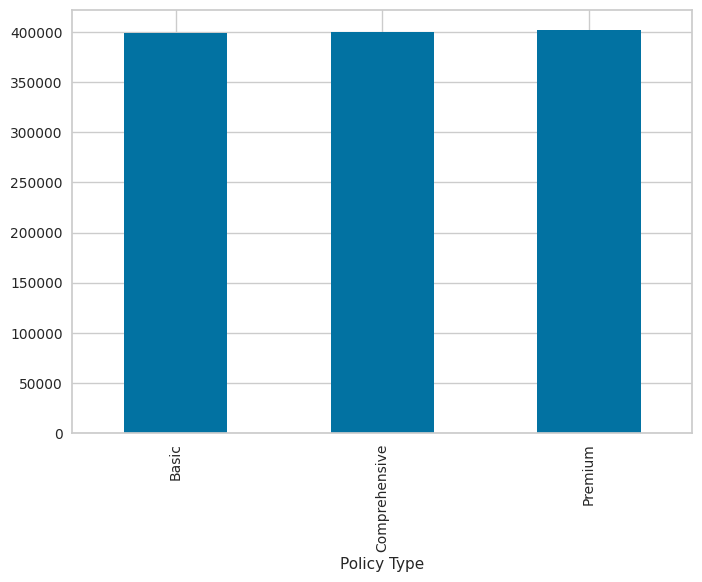

In [26]:
train_df.fillna('empty').groupby('Policy Type').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Basic')"}>,
        <Axes: title={'center': "('Premium Amount', 'Comprehensive')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Premium')"}>,
        <Axes: >]], dtype=object)

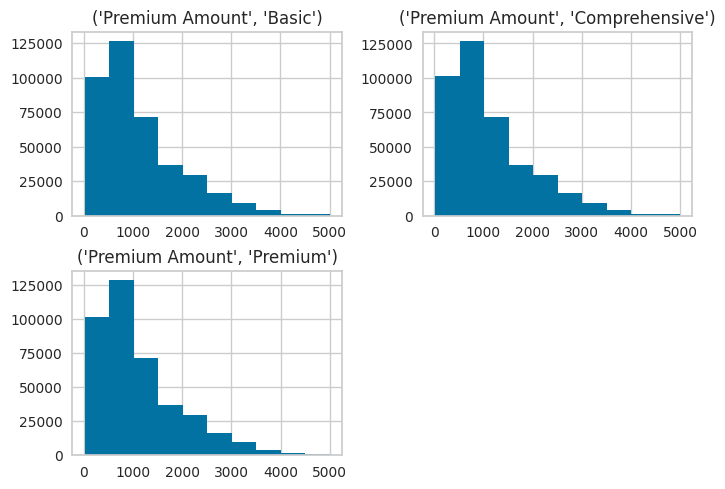

In [27]:
train_df.fillna('empty')[['Policy Type','Premium Amount']].pivot(columns='Policy Type').hist()

### Customer feedback

<Axes: xlabel='Customer Feedback'>

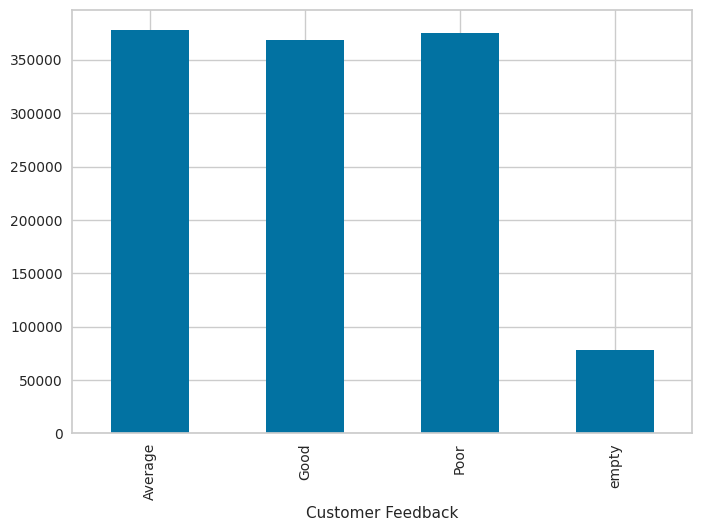

In [28]:
train_df.fillna('empty').groupby('Customer Feedback').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Average')"}>,
        <Axes: title={'center': "('Premium Amount', 'Good')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Poor')"}>,
        <Axes: title={'center': "('Premium Amount', 'empty')"}>]],
      dtype=object)

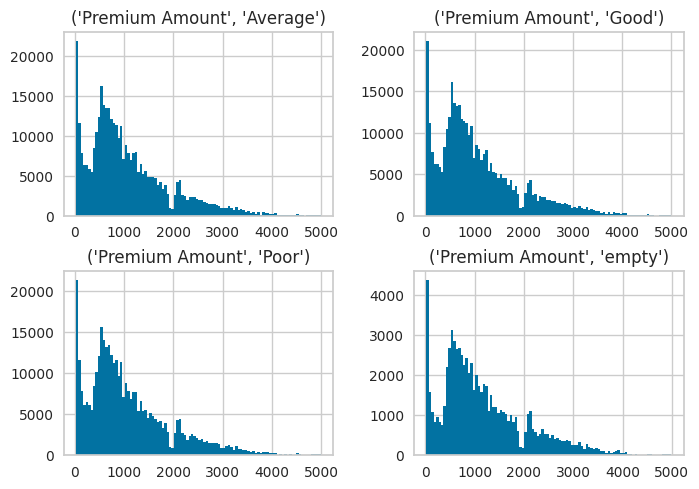

In [29]:
train_df.fillna('empty')[['Customer Feedback','Premium Amount']].pivot(columns='Customer Feedback').hist(bins=100)

### Smoking status

<Axes: xlabel='Smoking Status'>

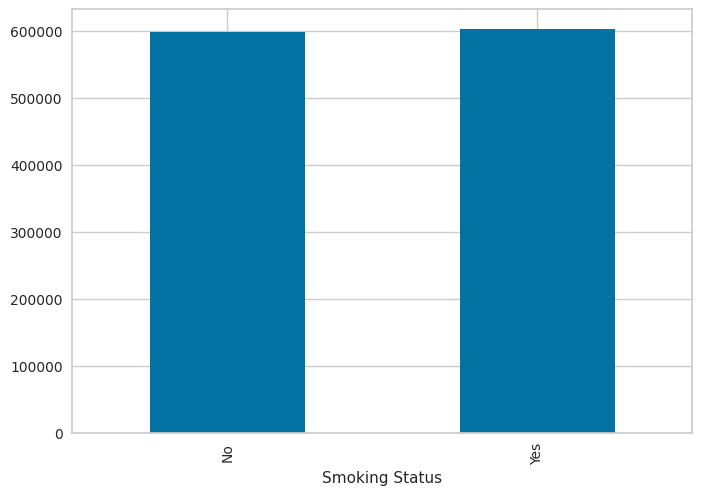

In [30]:
train_df.fillna('empty').groupby('Smoking Status').count()['id'].plot(kind='bar')

Smoking Status
No     [[Axes(0.125,0.11;0.775x0.77)]]
Yes    [[Axes(0.125,0.11;0.775x0.77)]]
dtype: object

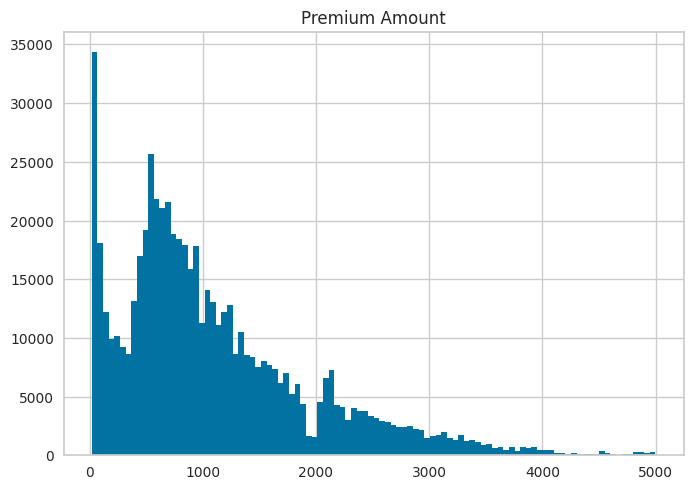

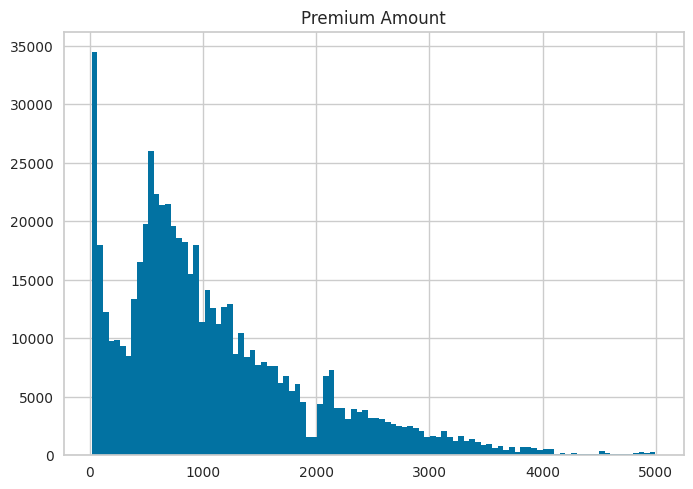

In [31]:
train_df.fillna('empty')[['Smoking Status','Premium Amount']].groupby('Smoking Status').hist(bins=100)

### Exercise frequency

<Axes: xlabel='Exercise Frequency'>

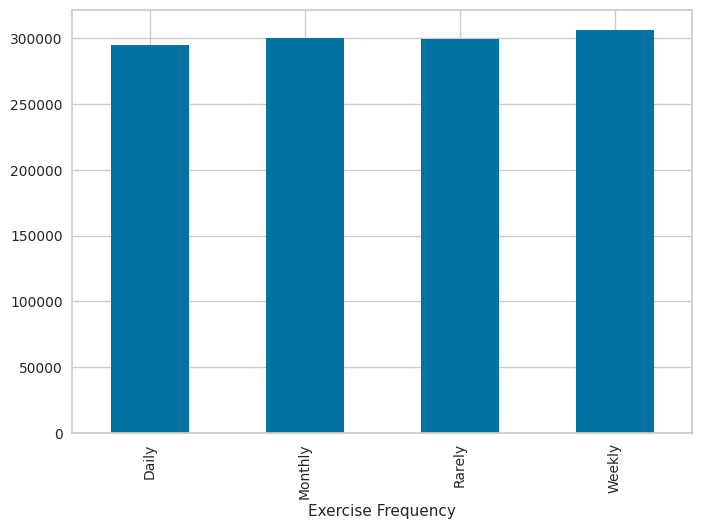

In [32]:
train_df.fillna('empty').groupby('Exercise Frequency').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Daily')"}>,
        <Axes: title={'center': "('Premium Amount', 'Monthly')"}>],
       [<Axes: title={'center': "('Premium Amount', 'Rarely')"}>,
        <Axes: title={'center': "('Premium Amount', 'Weekly')"}>]],
      dtype=object)

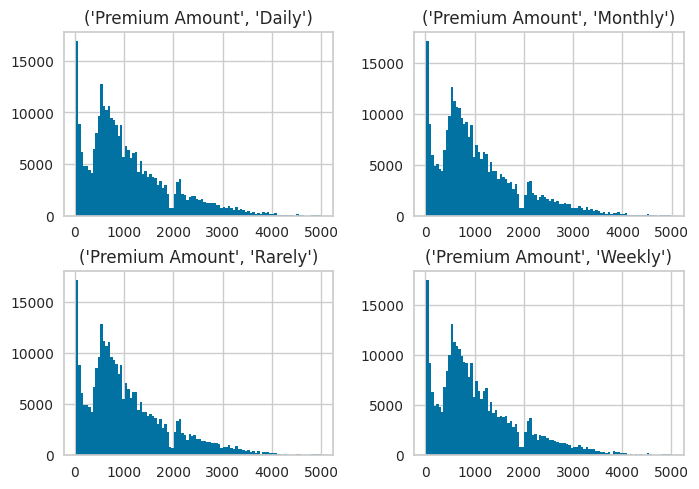

In [33]:
train_df.fillna('empty')[['Exercise Frequency','Premium Amount']].pivot(columns='Exercise Frequency').hist(bins=100)

### Property type

<Axes: xlabel='Property Type'>

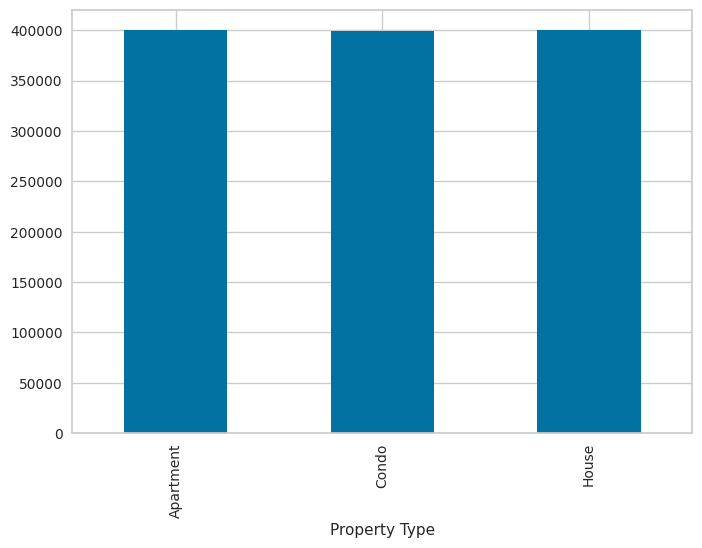

In [34]:
train_df.fillna('empty').groupby('Property Type').count()['id'].plot(kind='bar')

array([[<Axes: title={'center': "('Premium Amount', 'Apartment')"}>,
        <Axes: title={'center': "('Premium Amount', 'Condo')"}>],
       [<Axes: title={'center': "('Premium Amount', 'House')"}>,
        <Axes: >]], dtype=object)

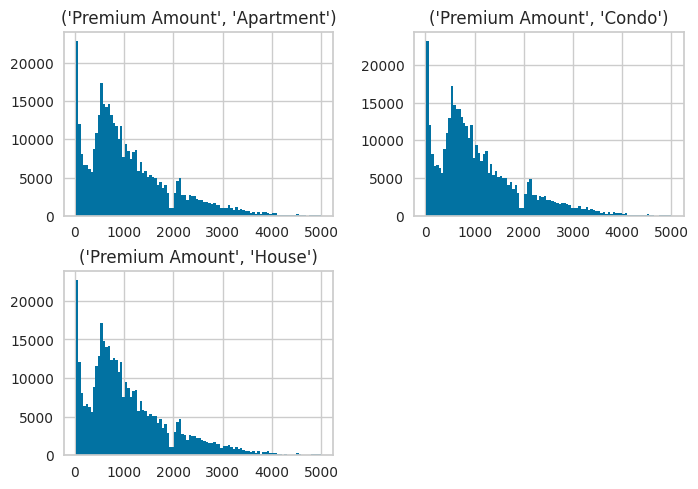

In [35]:
train_df.fillna('empty')[['Property Type','Premium Amount']].pivot(columns='Property Type').hist(bins=100)

# Regression

In [36]:
X = train_df.select_dtypes('number').notna().drop(columns='Premium Amount')
y = train_df.select_dtypes('number').notna()['Premium Amount']

In [37]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=42)


In [38]:
lr = linear_model.LinearRegression()#positive=True


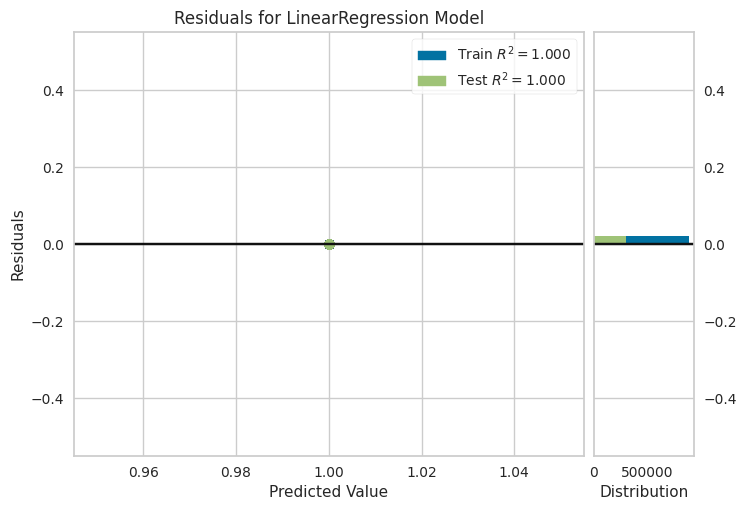

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [39]:
visualizer = ResidualsPlot(lr)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()   